In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


%matplotlib inline 


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,5)

print ("All Imports Successful")

All Imports Successful


In [2]:
df = pd.read_csv(
    "/Users/chetanm/Documents/Credit_Risk_Scorecard/data/raw/accepted_2007_to_2018Q4.csv.gz",
    compression = "gzip" , 
    low_memory =False 
)


print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Shape: (2260701, 151)
Rows: 2,260,701
Columns: 151


In [3]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.dtypes.value_counts()

float64    113
object      38
Name: count, dtype: int64

In [5]:
print(df["loan_status"].value_counts())
print()
print(df["loan_status"].value_counts(normalize=True).round(3)*100)

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

loan_status
Fully Paid                                             47.6
Current                                                38.9
Charged Off                                            11.9
Late (31-120 days)                                      0.9
In Grace Period                                         0.4
Late (16-30 days)                                       0.2
Does not meet the cred

In [6]:
# as seen from above there are a variety of type of loans included int he dataset , 
# we primarily jsut need the Fully Paid , Charged Off and Defaulted loans , while we filter out the others 

keep_status = ["Fully Paid", "Charged Off" , "Default"]
df = df[df["loan_status"].isin(keep_status)]

# create a sort of binary indicator of good(0) or bad(1) loans 
df["target"]  = (df["loan_status"].isin(["Charged Off", "Default"])).astype(int)

#runnign a verification 
print(f"Shape after fitlering: (df.shape)")
print()
print(df["target"].value_counts())
print()
print(df["target"].value_counts(normalize=True).round(3)*100)

Shape after fitlering: (df.shape)

target
0    1076751
1     268599
Name: count, dtype: int64

target
0    80.0
1    20.0
Name: proportion, dtype: float64


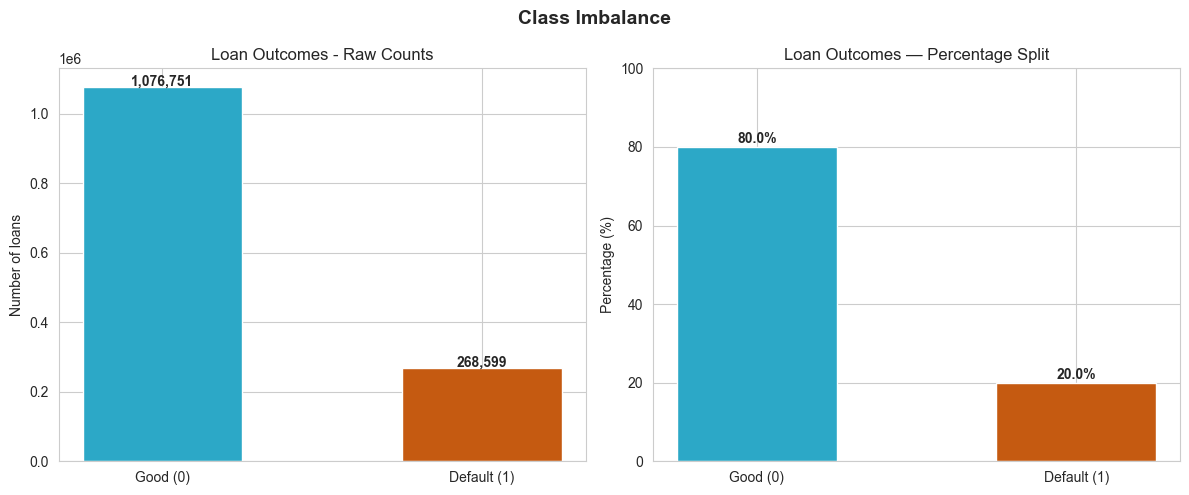

In [9]:
# trying to plot the imbalance 

fig, axes = plt.subplots(1,2, figsize = (12,5))

# left plot -> raw counts 
counts = df["target"].value_counts()
axes[0].bar(["Good (0)" , "Default (1)"], counts.values, color=["#2CA8C7","#C55A11"], width=0.5)
axes[0].set_title("Loan Outcomes - Raw Counts")
axes[0].set_ylabel("Number of loans")
for i,v in enumerate(counts.values):
    axes[0].text(i,v+5000,f"{v:,}", ha="center" , fontweight="bold")


# right plot - percentages 
percentages = df["target"].value_counts(normalize=True)*100
axes[1].bar(["Good (0)" , "Default (1)"], percentages.values, color=["#2CA8C7","#C55A11"],width=0.5)
axes[1].set_title("Loan Outcomes — Percentage Split")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 100)


for i, v in enumerate(percentages.values): 
    axes[1].text(i,v+1,f"{v:.1f}%",ha="center", fontweight="bold")

plt.suptitle("Class Imbalance", fontsize=14 , fontweight="bold")
plt.tight_layout() 
plt.show()

In [10]:
missing = (df.isnull().sum() / len(df)*100).sort_values(ascending=False)
missing = missing[missing>0]

print(f"Columns with missing values: {len(missing)} out of {df.shape[1]}")
print()
print(missing.head(20))

Columns with missing values: 105 out of 152

member_id                                     100.000000
next_pymnt_d                                   99.997027
orig_projected_additional_accrued_interest     99.720444
hardship_type                                  99.572156
hardship_reason                                99.572156
hardship_status                                99.572156
deferral_term                                  99.572156
hardship_amount                                99.572156
hardship_start_date                            99.572156
payment_plan_start_date                        99.572156
hardship_length                                99.572156
hardship_dpd                                   99.572156
hardship_loan_status                           99.572156
hardship_end_date                              99.572156
hardship_payoff_balance_amount                 99.572156
hardship_last_payment_amount                   99.572156
sec_app_mths_since_last_major_derog        

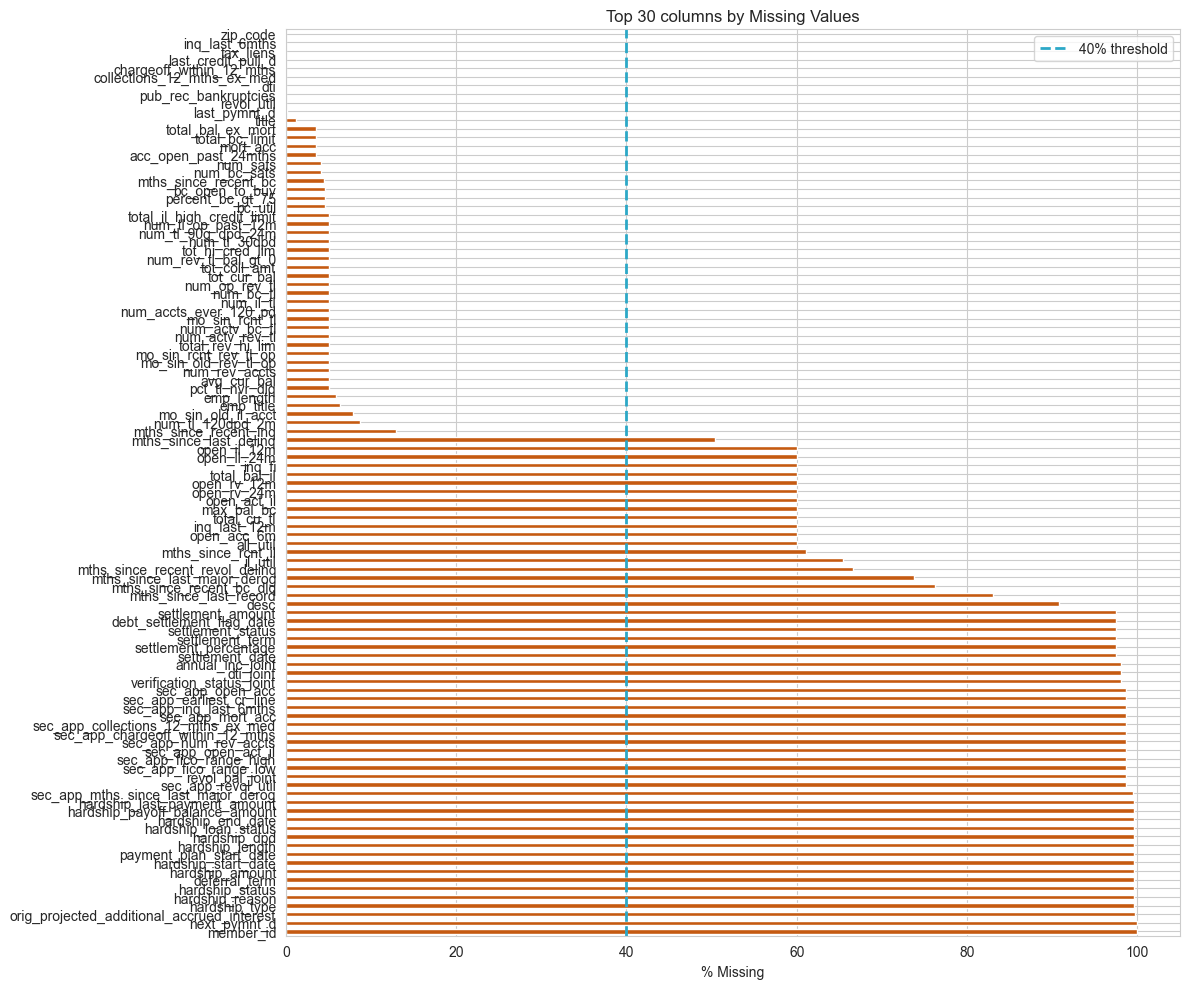

In [17]:
plt.figure(figsize=(12,10))
missing.head(300).plot(kind="barh", color="#C55A11")
plt.xlabel("% Missing")
plt.title("Top 30 columns by Missing Values")
plt.axvline(x=40, color="#2CA8C7", linestyle="--", linewidth = 2 , label = "40% threshold")
plt.legend() 
plt.tight_layout() 
plt.show()

In [19]:
# soemthing i noticed and would like to keep in mind going forward , often dataset are filled with sparsely populated variables , 
# which upon feeding into a model and training upon that would essentially be training it on noise , or very specifc cases which is bad imo 
# so food for thought going forward 

In [20]:
# dropping teh columns with more than 40 percent 
cols_to_drop = missing[missing > 40].index.tolist()

print(f"Columns to drop (>40% missing): {len(cols_to_drop)}")
print()
print(cols_to_drop)

df = df.drop(columns = cols_to_drop)

print()
print(f"Shape after dropping high missing value columns : {df.shape}")

Columns to drop (>40% missing): 58

['member_id', 'next_pymnt_d', 'orig_projected_additional_accrued_interest', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 'hardship_end_date', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'sec_app_mths_since_last_major_derog', 'sec_app_revol_util', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mort_acc', 'sec_app_inq_last_6mths', 'sec_app_earliest_cr_line', 'sec_app_open_acc', 'verification_status_joint', 'dti_joint', 'annual_inc_joint', 'settlement_date', 'settlement_percentage', 'settlement_term', 'settlement_status', 'debt_settlement_flag_date', 'settlement_amount', 'desc', 'mths_since_last_record', 'mths_since_recent_bc_

In [23]:
# now i'll remove those columns which hood info that the model will not have at time fo decisioning (basically to prevent  the mdoel from cheating :) , this is what is termed as data leakage)

In [25]:
leakage_cols = [
    "recoveries" , 
    "collection_recovery_fee",
    "last_pymnt_amnt",
    "last_pymnt_d",
    "last_credit_pull_d",
    "last_fico_range_high",
    "last_fico_range_low",
    "loan_status"
]


leakage_cols = [col for col in leakage_cols if col in df.columns] 
print(leakage_cols)

df = df.drop(columns = leakage_cols)

print(f"Dropped {len(leakage_cols)} leakage columns")
print(f"Shape after dropping leakage columns : {df.shape}")


['recoveries', 'collection_recovery_fee', 'last_pymnt_amnt', 'last_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'loan_status']
Dropped 8 leakage columns
Shape after dropping leakage columns : (1345350, 86)


In [26]:
df.to_csv("../data/processed/df_cleaned.csv", index=False)
print("Saved to data/processed/df_cleaned.csv")
print(f"Shape: {df.shape}")

Saved to data/processed/df_cleaned.csv
Shape: (1345350, 86)


In [57]:
#use this to reload data from teh checkpoint

df = pd.read_csv("../data/processed/df_cleaned.csv", low_memory=False)
print(f"Shape: {df.shape}")

Shape: (1345350, 86)


In [51]:
# plotting specific featyures , which are most important from a high elvel view 

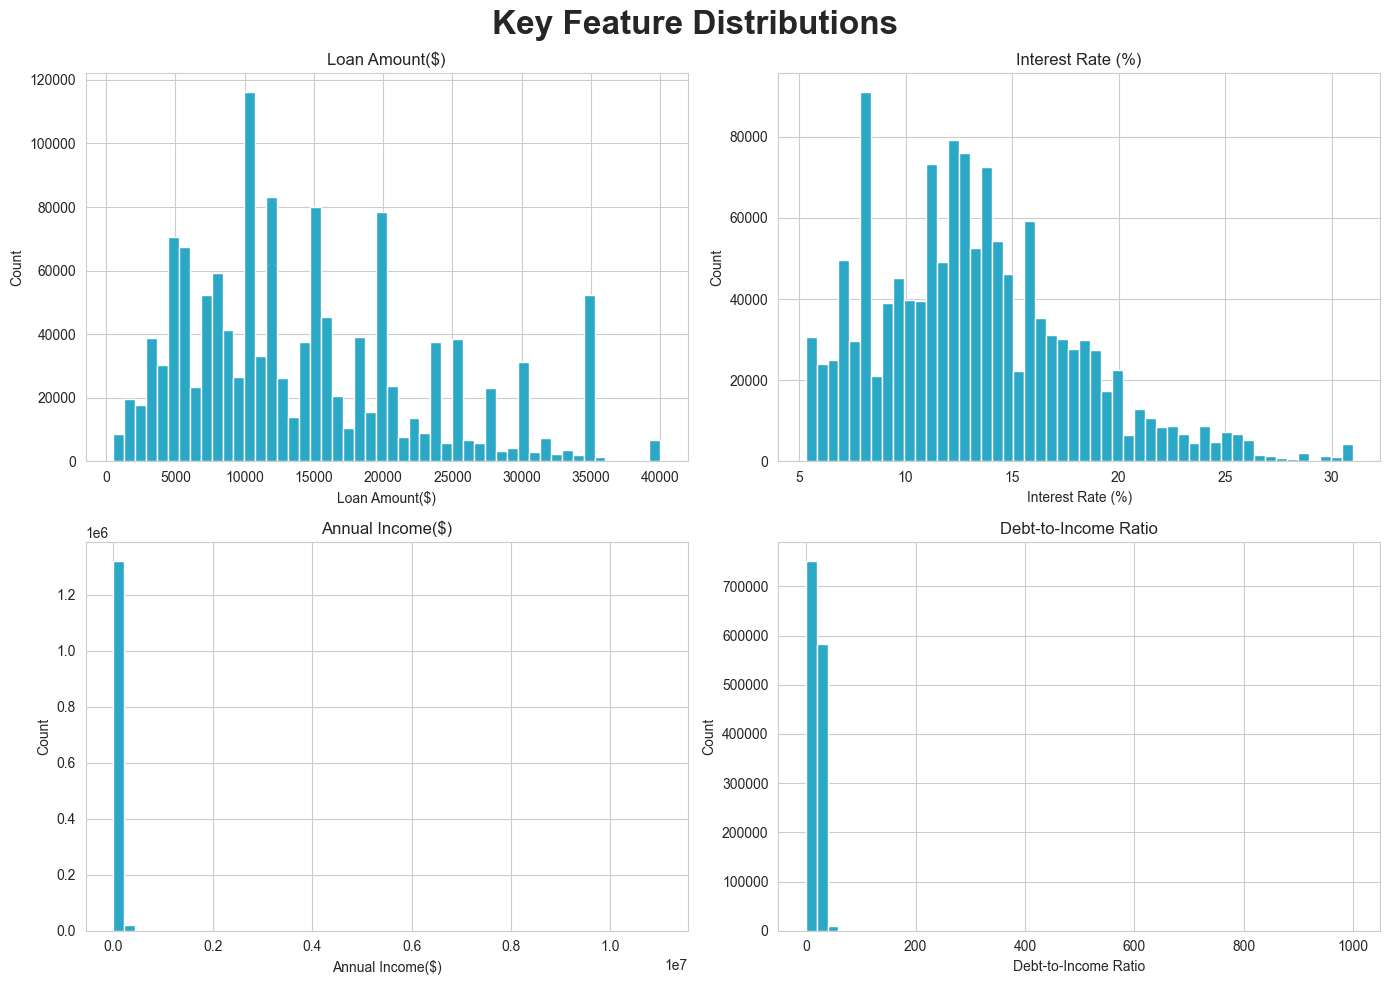

In [58]:
fig, axes = plt.subplots(2,2, figsize =(14,10))

features = {
    "loan_amnt": "Loan Amount($)",
    "int_rate": "Interest Rate (%)",
    "annual_inc": "Annual Income($)" , 
    "dti": "Debt-to-Income Ratio"
}

for ax, (col,label) in zip(axes.flatten(), features.items()): 
        df[col].hist(bins=50, ax=ax, color="#2CA8C7", edgecolor="white")
        ax.set_title(label)
        ax.set_xlabel(label)
        ax.set_ylabel("Count")

plt.suptitle("Key Feature Distributions" , fontsize=24 , fontweight="bold")
plt.tight_layout()
plt.show()

In [59]:
print("Annual Income stats:")
print(df["annual_inc"].describe())
print()
print("DTI stats:")
print(df["dti"].describe())

Annual Income stats:
count    1.345350e+06
mean     7.624757e+04
std      6.992485e+04
min      0.000000e+00
25%      4.578000e+04
50%      6.500000e+04
75%      9.000000e+04
max      1.099920e+07
Name: annual_inc, dtype: float64

DTI stats:
count    1.344976e+06
mean     1.828264e+01
std      1.116041e+01
min     -1.000000e+00
25%      1.179000e+01
50%      1.761000e+01
75%      2.406000e+01
max      9.990000e+02
Name: dti, dtype: float64


In [60]:
print("Annual Income 99.99th percentile:", df["annual_inc"].quantile(0.9999))
print("DTI 99th percentile:", df["dti"].quantile(0.99))
print("DTI 99.5th percentile:", df["dti"].quantile(0.995))
print("DTI 99.9th percentile:", df["dti"].quantile(0.999))
print()
print("Annual Income 95th percentile:", df["annual_inc"].quantile(0.95))
print("DTI 95th percentile:", df["dti"].quantile(0.95))
print()
print("Rows above annual_inc 99th percentile:", (df["annual_inc"] > df["annual_inc"].quantile(0.99)).sum())
print("Rows above dti 99th percentile:", (df["dti"] > df["dti"].quantile(0.99)).sum())
print("Rows with dti < 0:", (df["dti"] < 0).sum())

Annual Income 99.99th percentile: 1500000.0
DTI 99th percentile: 38.47
DTI 99.5th percentile: 40.07125
DTI 99.9th percentile: 66.08050000000279

Annual Income 95th percentile: 155000.0
DTI 95th percentile: 32.99

Rows above annual_inc 99th percentile: 13448
Rows above dti 99th percentile: 13446
Rows with dti < 0: 2


In [61]:
# Dropping Outliers

inc_threshold = df["annual_inc"].quantile(0.999)
dti_threshold = df["dti"].quantile(0.999)

print(f"Annual Income Threshold : ${inc_threshold:,.0f}")
print(f"DTI Threshold: {dti_threshold:.2f}")

initial_rows = len(df)

df = df[
    (df["annual_inc"] <= inc_threshold) &
    (df["annual_inc"] > 0) &
    (df["dti"] <= dti_threshold) &
    (df["dti"] >= 0)
]

dropped = initial_rows - len(df)
print(f"\nRows dropped: {dropped:,}")
print(f"Rows remaining: {len(df):,}")
print(f"% dropped: {dropped/initial_rows*100:.2f}%")


Annual Income Threshold : $577,302
DTI Threshold: 66.08

Rows dropped: 3,067
Rows remaining: 1,342,283
% dropped: 0.23%


In [62]:
df.to_csv("../data/processed/df_cleaned_2.csv", index=False)
print("Checkpoint updated")
print(f"Final shape: {df.shape}")

Checkpoint updated
Final shape: (1342283, 86)


In [66]:
# splitting the training and test dataset : theory behind that 
# A random split doesn't test this at all. If you randomly mix 2016–2020 data, 
# your test set contains loans from the same economic environment as your training set. 
# The model looks great on paper but you have no idea if it actually generalises to new conditions.
# An out-of-time split — train on 2016–2018, test on 2019–2020 — genuinely simulates deployment. 
# The model has never seen 2019–2020 data during training. 
# If it performs well on that test set, you have real confidence it will work in production.

In [67]:
print(df["issue_d"].dtype)
print(df["issue_d"].value_counts().sort_index().head(10))

object
issue_d
Apr-2008      155
Apr-2009      290
Apr-2010      825
Apr-2011     1563
Apr-2012     3227
Apr-2013     9411
Apr-2014    18162
Apr-2015    31767
Apr-2016    24060
Apr-2017    13035
Name: count, dtype: int64


In [73]:
# Convert to datetime
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")

# Check the range
print("Earliest loan:", df["issue_d"].min())
print("Latest loan:", df["issue_d"].max())
print()
print("Loans by year:")
print(df["issue_d"].dt.year.value_counts().sort_index())

Earliest loan: 2007-06-01 00:00:00
Latest loan: 2018-12-01 00:00:00

Loans by year:
issue_d
2007       250
2008      1561
2009      4703
2010     11509
2011     21710
2012     53333
2013    134728
2014    222944
2015    375140
2016    292547
2017    168218
2018     55640
Name: count, dtype: int64


In [75]:
train = df[df["issue_d"].dt.year.between(2010,2015)]
test = df[df["issue_d"].dt.year.between(2016,2018)]


print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print()
print(f"Train years: {train['issue_d'].dt.year.min()} - {train['issue_d'].dt.year.max()}")
print(f"Test years: {test['issue_d'].dt.year.min()} - {test['issue_d'].dt.year.max()}")
print()
print("Train target distribution:")
print(train["target"].value_counts(normalize=True).round(3)*100)
print()
print("Test target distribution:")
print(test["target"].value_counts(normalize=True).round(3)*100)

Train shape: (819364, 87)
Test shape: (516405, 87)

Train years: 2010 - 2015
Test years: 2016 - 2018

Train target distribution:
target
0    81.5
1    18.5
Name: proportion, dtype: float64

Test target distribution:
target
0    77.6
1    22.4
Name: proportion, dtype: float64


In [76]:
train.to_csv("../data/processed/train.csv", index=False)
test.to_csv("../data/processed/test.csv", index=False)

print("Train saved: data/processed/train.csv")
print("Test saved: data/processed/test.csv")
print()
print(f"Train: {train.shape[0]:,} rows")
print(f"Test: {test.shape[0]:,} rows")
print()
print("IMPORTANT: Test set is now locked.")
print("Do not touch it again until Phase 4 validation.")

Train saved: data/processed/train.csv
Test saved: data/processed/test.csv

Train: 819,364 rows
Test: 516,405 rows

IMPORTANT: Test set is now locked.
Do not touch it again until Phase 4 validation.


In [1]:
import statsmodels.api as sm
print(sm.__version__)

0.14.6


In [8]:
train = pd.read_csv("../data/processed/train.csv", low_memory=False)
# print(f"Shape: {df.shape}")

#Check missing values in train set
missing_train = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing_train = missing_train[missing_train > 0]

print(f"Columns still with missing values: {len(missing_train)}")
print()
print(missing_train.head(20))

test = pd.read_csv("../data/processed/test.csv", low_memory=False)
missing_test = (test.isnull().sum() / len(test) * 100).sort_values(ascending=False)
missing_test = missing_test[missing_test > 0]

print(f"Columns still with missing values: {len(missing_test)}")
print()
print(missing_test.head(20))

Columns still with missing values: 38

mths_since_recent_inq    14.642943
num_tl_120dpd_2m         10.553551
mo_sin_old_il_acct       10.409659
pct_tl_nvr_dlq            7.457491
avg_cur_bal               7.440283
num_rev_accts             7.438940
mo_sin_old_rev_tl_op      7.438940
mo_sin_rcnt_rev_tl_op     7.438940
num_bc_tl                 7.438818
num_rev_tl_bal_gt_0       7.438818
num_op_rev_tl             7.438818
num_il_tl                 7.438818
tot_cur_bal               7.438818
num_actv_rev_tl           7.438818
num_actv_bc_tl            7.438818
tot_coll_amt              7.438818
num_tl_30dpd              7.438818
mo_sin_rcnt_tl            7.438818
num_accts_ever_120_pd     7.438818
total_rev_hi_lim          7.438818
dtype: float64
Columns still with missing values: 15

mths_since_recent_inq    9.154055
emp_title                6.935448
emp_length               6.786534
num_tl_120dpd_2m         4.699412
title                    3.195941
mo_sin_old_il_acct       2.643274
bc_

In [9]:
cols_with_missing = missing_train[missing_train > 0].index.tolist()

print("=== BEFORE IMPUTATION ===")
train[cols_with_missing].describe().round(2)

=== BEFORE IMPUTATION ===


,mths_since_recent_inq,num_tl_120dpd_2m,mo_sin_old_il_acct,pct_tl_nvr_dlq,avg_cur_bal,num_rev_accts,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,num_bc_tl,num_rev_tl_bal_gt_0,...,num_bc_sats,bc_util,percent_bc_gt_75,bc_open_to_buy,mths_since_recent_bc,acc_open_past_24mths,mort_acc,total_bal_ex_mort,total_bc_limit,revol_util
count,699385.00,732892.00,734071.00,758260.0,758401.00,758412.00,758412.00,758412.00,758413.00,758413.00,...,770097.00,770707.00,770797.00,771179.00,771718.00,778651.00,778651.00,778651.00,778651.00,818945.00
mean,6.82,0.00,126.70,94.3,13173.26,15.02,183.41,13.27,8.44,5.73,...,4.71,63.58,49.37,8977.40,24.55,4.46,1.75,48155.78,20721.06,54.79
std,5.89,0.03,51.67,8.5,15693.47,8.06,93.14,16.38,4.84,3.17,...,2.83,27.09,35.43,14036.59,30.69,3.01,2.09,45181.45,20518.50,23.79
min,0.00,0.00,0.00,7.7,0.00,0.00,3.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2.00,0.00,99.00,91.7,3069.00,9.00,118.00,4.00,5.00,4.00,...,3.00,43.90,20.00,1201.00,6.00,2.00,0.00,20674.50,7500.00,37.40
50%,5.00,0.00,129.00,98.0,7230.00,14.00,166.00,8.00,8.00,5.00,...,4.00,67.80,50.00,3937.00,14.00,4.00,1.00,36513.00,14400.00,55.60
75%,10.00,0.00,153.00,100.0,18358.00,19.00,231.00,16.00,11.00,7.00,...,6.00,87.10,80.00,10632.00,30.00,6.00,3.00,60595.00,27000.00,73.20
max,25.00,6.00,724.00,100.0,958084.00,112.00,851.00,372.00,70.00,45.00,...,63.00,339.60,100.00,559912.00,616.00,64.00,37.00,2921551.00,571500.00,892.30


In [11]:
median_values = train.median(numeric_only = True)

train = train.fillna(median_values)

test = test.fillna(median_values)

print("Missing values in train after imputation:")
print(train.isnull().sum()[train.isnull().sum() > 0])
print()
print("Missing Values in test after imputation:")
print(test.isnull().sum()[test.isnull().sum() > 0])

Missing values in train after imputation:
emp_title     48669
emp_length    42557
title           136
dtype: int64

Missing Values in test after imputation:
emp_title     35815
emp_length    35046
title         16504
zip_code          1
dtype: int64


In [15]:
print(train["title"].value_counts().head(10))
print()
print(train["purpose"].value_counts())
print()
print(train["emp_length"].value_counts())
print()
print(train["emp_title"].value_counts())
print()
print(train["zip_code"].nunique())

title
Debt consolidation         377782
Credit card refinancing    149312
Home improvement            36671
Other                       30199
Debt Consolidation          15458
Major purchase              11144
Medical expenses             6349
Business                     6319
Consolidation                5298
Car financing                5221
Name: count, dtype: int64

purpose
debt_consolidation    484229
credit_card           189936
home_improvement       47710
other                  39935
major_purchase         15941
small_business          9372
car                     8250
medical                 8045
moving                  5134
vacation                4603
house                   3450
wedding                 2108
renewable_energy         548
educational              103
Name: count, dtype: int64

emp_length
10+ years    267091
2 years       72903
3 years       64826
< 1 year      64723
1 year        52573
5 years       51852
4 years       48640
7 years       41581
8 years       4

In [16]:
print(train["zip_code"].nunique())

931


In [17]:
cols_to_drop = ["emp_title", "title", "zip_code"]
train = train.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)


# clean emp_length - convert to numeric 

emp_length_map = {
    "< 1 year": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10
}


train["emp_length"] = train["emp_length"].map(emp_length_map)
test["emp_length"] = test["emp_length"].map(emp_length_map)

# Any remaining NaN in emp_length — impute with train median
emp_length_median = train["emp_length"].median()
train["emp_length"] = train["emp_length"].fillna(emp_length_median)
test["emp_length"] = test["emp_length"].fillna(emp_length_median)

#veirfication 
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print()
print("emp_length unique value:", sorted(train["emp_length"].unique()))
print("emp_length missing: ", train["emp_length"].isnull().sum())



Train shape: (819364, 84)
Test shape: (516405, 84)

emp_length unique value: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]
emp_length missing:  0


In [18]:
print("Remaining missing values in train:")
remaining = train.isnull().sum()
remaining = remaining[remaining > 0]
print(remaining if len(remaining) > 0 else "None — all clean")
print()
print("Remaining missing values in test:")
remaining_test = test.isnull().sum()
remaining_test = remaining_test[remaining_test > 0]
print(remaining_test if len(remaining_test) > 0 else "None — all clean")

Remaining missing values in train:
None — all clean

Remaining missing values in test:
None — all clean


In [19]:
train.to_csv("../data/processed/train.csv", index=False)
test.to_csv("../data/processed/test.csv", index=False)

print("Saved successfully")
print(f"Train: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Test: {test.shape[0]:,} rows x {test.shape[1]} columns")

Saved successfully
Train: 819,364 rows x 84 columns
Test: 516,405 rows x 84 columns


In [6]:
#use this to reload data from teh checkpoint

train = pd.read_csv("../data/processed/train.csv", low_memory=False)
print(f"Shape: {train.shape}")

test = pd.read_csv("../data/processed/test.csv", low_memory=False)
print(f"Shape: {test.shape}")

# Separate numeric and non-numeric columns
numeric_cols = train.select_dtypes(include=["number"]).columns.tolist()
non_numeric_cols = train.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print()
print(f"Non-numeric columns: {len(non_numeric_cols)}")
print(non_numeric_cols)

Shape: (819364, 84)
Shape: (516405, 84)
Numeric columns: 67

Non-numeric columns: 17
['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'issue_d', 'pymnt_plan', 'url', 'purpose', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag', 'issues_d']


In [11]:
# we dorp url , issues_d , issue_d 


print(train["pymnt_plan"].value_counts().head(5))
print()
print(train["issues_d"].value_counts().head(5))
print()
print(train["earliest_cr_line"].head(10))

pymnt_plan
n    819364
Name: count, dtype: int64

issues_d
2015-10-01    42933
2015-07-01    41014
2015-12-01    38943
2014-10-01    36039
2015-11-01    32850
Name: count, dtype: int64

0    Aug-2003
1    Dec-1999
2    Aug-2000
3    Jun-1998
4    Oct-1987
5    Jun-1990
6    Feb-1999
7    Apr-2002
8    Nov-1994
9    Jun-1996
Name: earliest_cr_line, dtype: object


In [21]:
# import pandas as pd 

# def add_credit_history_months(df) : 
#     # Parse to datatime
#     df["issue_d"] = pd.to_datetime(df["issue_d"])
#     df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"])

#     #computingthe credit history in months 
#     df["credit_history_months"] = (
#         df["issue_d"].dt.year - df["earliest_cr_line"].dt.year * 12 +
#             df["issue_d"].dt.month - df["earliest_cr_line"].dt.month
#     )

#     #drop the columns which are no longer needed 
#     cols_to_drop = ["issue_d" , "earliest_cr_line" , "url" , "issues_d" , "pymnt_plan"]
#     df.drop(columns=cols_to_drop)

#     return df

# train = pd.read_csv("../data/processed/train.csv", low_memory=False)
# test = pd.read_csv("../data/processed/test.csv", low_memory=False)

# train = add_credit_history_months(train)
# test = add_credit_history_months(test)

# print(train["credit_history_months"].describe())
# print(f"\nTrain shape: {train.shape}")
# print(f"Test shape: {test.shape}")

train = pd.read_csv("../data/processed/train.csv", low_memory=False)
test = pd.read_csv("../data/processed/test.csv", low_memory=False)

for df in [train, test]:
    df["issue_d"] = pd.to_datetime(df["issue_d"])
    df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y")
    df["credit_history_months"] = (
        (df["issue_d"].dt.year - df["earliest_cr_line"].dt.year) * 12 +
        (df["issue_d"].dt.month - df["earliest_cr_line"].dt.month)
    )

cols_to_drop = ["issue_d", "earliest_cr_line", "url", "issues_d", "pymnt_plan"]
train = train.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)

print(train["credit_history_months"].describe())
print(f"\nTrain shape: {train.shape}")
print(f"Test shape: {test.shape}")

count    819364.000000
mean        195.192031
std          89.319812
min          36.000000
25%         135.000000
50%         177.000000
75%         240.000000
max         852.000000
Name: credit_history_months, dtype: float64

Train shape: (819364, 80)
Test shape: (516405, 80)


In [22]:
train.to_csv("../data/processed/train.csv", index=False)
test.to_csv("../data/processed/test.csv", index=False)
print("Saved.")

Saved.


In [17]:
train = pd.read_csv("../data/processed/train.csv", low_memory=False)
test = pd.read_csv("../data/processed/test.csv", low_memory=False)

# Count goods and bads per grade bin

woe_table = train.groupby("grade")["target"].agg(
    total="count",
    bads="sum"
)
woe_table["goods"] = woe_table["total"] - woe_table["bads"]
print(woe_table)

        total   bads   goods
grade                       
A      144705   8049  136656
B      239374  28808  210566
C      223369  45580  177789
D      125006  35246   89760
E       61494  22659   38835
F       20587   8730   11857
G        4829   2261    2568


In [11]:
total_goods = woe_table["goods"].sum()
total_bads = woe_table["bads"].sum()

woe_table["pct_goods"] = woe_table["goods"] / total_goods
woe_table["pct_bads"] = woe_table["bads"] / total_bads
woe_table["woe"] = np.log(woe_table["pct_goods"] / woe_table["pct_bads"])
woe_table["iv_bin"] = (woe_table["pct_goods"] - woe_table["pct_bads"]) * woe_table["woe"]

iv_grade = woe_table["iv_bin"].sum()

print(woe_table[["pct_goods", "pct_bads", "woe", "iv_bin"]])
print(f"\nIV for grade: {iv_grade:.4f}")

       pct_goods  pct_bads       woe    iv_bin
grade                                         
A       0.204565  0.053187  1.347067  0.203916
B       0.315204  0.190362  0.504294  0.062957
C       0.266139  0.301190 -0.123723  0.004337
D       0.134365  0.232904 -0.550064  0.054203
E       0.058134  0.149729 -0.946087  0.086658
F       0.017749  0.057687 -1.178699  0.047075
G       0.003844  0.014941 -1.357532  0.015064

IV for grade: 0.4742


In [12]:
print(train.dtypes.to_string())

id                              int64
loan_amnt                     float64
funded_amnt                   float64
funded_amnt_inv               float64
term                           object
int_rate                      float64
installment                   float64
grade                          object
sub_grade                      object
emp_length                    float64
home_ownership                 object
annual_inc                    float64
verification_status            object
purpose                        object
addr_state                     object
dti                           float64
delinq_2yrs                   float64
fico_range_low                float64
fico_range_high               float64
inq_last_6mths                float64
open_acc                      float64
pub_rec                       float64
revol_bal                     float64
revol_util                    float64
total_acc                     float64
initial_list_status            object
out_prncp   

In [14]:
print(train["policy_code"].value_counts())
print(test["policy_code"].value_counts())

policy_code
1.0    819364
Name: count, dtype: int64
policy_code
1.0    516405
Name: count, dtype: int64


In [18]:
cols_to_drop = [
    # identifiers
    "id",
    # zero variance
    "policy_code",
    # post-issue leakage
    "out_prncp", "out_prncp_inv",
    "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
    "hardship_flag", "debt_settlement_flag",
    "disbursement_method"
]

train = train.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (819364, 68)
Test shape: (516405, 68)


In [20]:
categorical_cols = [
    "term", "grade" , "sub_grade" , "home_ownership" , "verification_status" , 
    "purpose" , "addr_state" , "initial_list_status" , "application_type"
]

numeric_cols = [col for col in train.columns if col not in categorical_cols + ["target"]]

print(f"Categorical columns: {len(categorical_cols)}")
print(categorical_cols)
print(f"\nNumeric columns: {len(numeric_cols)}")
print(numeric_cols)

Categorical columns: 9
['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type']

Numeric columns: 58
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_

In [21]:
cols_to_drop_2 = [
    "int_rate",
    "installment", 
    "funded_amnt",
    "funded_amnt_inv"
]

train = train.drop(columns=cols_to_drop_2)
test = test.drop(columns=cols_to_drop_2)

categorical_cols = [
    "term", "grade", "sub_grade", "home_ownership", "verification_status",
    "purpose", "addr_state", "initial_list_status", "application_type"
]

numeric_cols = [col for col in train.columns 
                if col not in categorical_cols + ["target"]]

print(f"Train shape: {train.shape}")
print(f"\nCategorical columns: {len(categorical_cols)}")
print(f"Numeric columns: {len(numeric_cols)}")
print(numeric_cols)

Train shape: (819364, 64)

Categorical columns: 9
Numeric columns: 54
['loan_amnt', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'to

In [22]:
train = train.drop(columns=["fico_range_high"])
test = test.drop(columns=["fico_range_high"])

numeric_cols = [col for col in train.columns 
                if col not in categorical_cols + ["target"]]

print(f"Train shape: {train.shape}")
print(f"Numeric columns: {len(numeric_cols)}")

Train shape: (819364, 63)
Numeric columns: 53


In [23]:
train.to_csv("../data/processed/train.csv", index=False)
test.to_csv("../data/processed/test.csv", index=False)
print("Saved.")

Saved.


In [27]:
from optbinning import OptimalBinning
import numpy as np

target_values = train["target"].values
binning_models = {}  # store fitted models here
iv_results = []

feature_cols = [col for col in train.columns if col != "target"]
categorical_cols_final = ["sub_grade", "term", "verification_status", 
                           "home_ownership", "purpose"]
numeric_cols_final = [col for col in feature_cols 
                      if col not in categorical_cols_final]

for col in feature_cols:
    dtype = "numerical" if col in numeric_cols_final else "categorical"
    
    optb = OptimalBinning(name=col, dtype=dtype, solver="cp")
    optb.fit(train[col].values, target_values)
    
    binning_models[col] = optb  # save the fitted model
    
    binning_table = optb.binning_table.build()
    iv = binning_table["IV"].iloc[-1]
    iv_results.append({"feature": col, "iv": iv, "dtype": dtype})
    print(f"Done: {col} | IV: {iv:.4f}")

iv_table = pd.DataFrame(iv_results).sort_values("iv", ascending=False).reset_index(drop=True)
print("\nFitting complete.")
print(f"Models stored: {len(binning_models)}")

Done: sub_grade | IV: 0.5056
Done: term | IV: 0.2411
Done: verification_status | IV: 0.0514
Done: home_ownership | IV: 0.0212
Done: purpose | IV: 0.0179
Done: fico_range_low | IV: 0.1213
Done: acc_open_past_24mths | IV: 0.0814
Done: dti | IV: 0.0758
Done: num_tl_op_past_12m | IV: 0.0585
Done: bc_open_to_buy | IV: 0.0555
Done: avg_cur_bal | IV: 0.0406
Done: mo_sin_rcnt_tl | IV: 0.0404
Done: total_bc_limit | IV: 0.0390
Done: loan_amnt | IV: 0.0370
Done: tot_hi_cred_lim | IV: 0.0367
Done: tot_cur_bal | IV: 0.0327
Done: annual_inc | IV: 0.0324
Done: mths_since_recent_inq | IV: 0.0304
Done: mo_sin_rcnt_rev_tl_op | IV: 0.0302
Done: percent_bc_gt_75 | IV: 0.0299
Done: num_actv_rev_tl | IV: 0.0294
Done: num_rev_tl_bal_gt_0 | IV: 0.0286
Done: inq_last_6mths | IV: 0.0278
Done: bc_util | IV: 0.0273
Done: mths_since_recent_bc | IV: 0.0269
Done: mort_acc | IV: 0.0255
Done: total_rev_hi_lim | IV: 0.0249
Done: revol_util | IV: 0.0224
Done: mo_sin_old_rev_tl_op | IV: 0.0220
Done: credit_history_months

In [25]:
features_to_keep = [
    # categorical
    "sub_grade", "term", "verification_status", "home_ownership", "purpose",
    # numerical
    "fico_range_low", "acc_open_past_24mths", "dti", "num_tl_op_past_12m",
    "bc_open_to_buy", "avg_cur_bal", "mo_sin_rcnt_tl", "total_bc_limit",
    "loan_amnt", "tot_hi_cred_lim", "tot_cur_bal", "annual_inc",
    "mths_since_recent_inq", "mo_sin_rcnt_rev_tl_op", "percent_bc_gt_75",
    "num_actv_rev_tl", "num_rev_tl_bal_gt_0", "inq_last_6mths", "bc_util",
    "mths_since_recent_bc", "mort_acc", "total_rev_hi_lim", "revol_util",
    "mo_sin_old_rev_tl_op", "credit_history_months"
]

# Add target
cols_final = features_to_keep + ["target"]

train = train[cols_final]
test = test[cols_final]

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nFinal feature count: {len(features_to_keep)}")

Train shape: (819364, 31)
Test shape: (516405, 31)

Final feature count: 30


In [26]:
train.to_csv("../data/processed/train_selected.csv", index=False)
test.to_csv("../data/processed/test_selected.csv", index=False)
print("Saved.")

Saved.


In [28]:
def apply_woe_transformation(df, binning_models, feature_cols):
    df_woe = df.copy()
    for col in feature_cols:
        optb = binning_models[col]
        df_woe[col] = optb.transform(df[col].values, metric="woe")
    return df_woe

feature_cols = [col for col in train.columns if col != "target"]

train_woe = apply_woe_transformation(train, binning_models, feature_cols)
test_woe = apply_woe_transformation(test, binning_models, feature_cols)

print(f"Train WoE shape: {train_woe.shape}")
print(f"Test WoE shape: {test_woe.shape}")
print(f"\nSample WoE values for sub_grade:")
print(train_woe["sub_grade"].value_counts().head())

Train WoE shape: (819364, 31)
Test WoE shape: (516405, 31)

Sample WoE values for sub_grade:
sub_grade
-0.355134    69943
 1.326937    56835
 0.521314    52810
 0.374013    51752
-0.526039    50791
Name: count, dtype: int64


In [29]:
train_woe.to_csv("../data/processed/train_woe.csv", index=False)
test_woe.to_csv("../data/processed/test_woe.csv", index=False)
print("Saved.")

Saved.


In [30]:
train_woe = pd.read_csv("../data/processed/train_woe.csv", low_memory=False)
test_woe = pd.read_csv("../data/processed/test_woe.csv", low_memory=False)

In [33]:
import statsmodels.api as sm 

# Separate features and targets 
x_train = train_woe.drop(columns=["target"])
y_train = train_woe["target"]

x_test = test_woe.drop(columns=["target"])
y_test = test_woe["target"]

# Add constant (intercept)
x_train_const = sm.add_constant(x_train)
x_test_const = sm.add_constant(x_test)

#Fit logistic regression
logit_model = sm.Logit(y_train, x_train_const)
result = logit_model.fit()

print(result.summary())


Optimization terminated successfully.
         Current function value: 0.430316
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:               819364
Model:                          Logit   Df Residuals:                   819333
Method:                           MLE   Df Model:                           30
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.1006
Time:                        08:37:21   Log-Likelihood:            -3.5259e+05
converged:                       True   LL-Null:                   -3.9202e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.4871      0.003   -480.918      0.000      -1.493      -1.

In [34]:
print(binning_models["credit_history_months"].binning_table.build())

                     Bin   Count  Count (%)  Non-event   Event  Event rate  \
0          (-inf, 81.50)   48547   0.059250      38543   10004    0.206068   
1        [81.50, 133.50)  151733   0.185184     121192   30541    0.201281   
2       [133.50, 145.50)   55669   0.067942      44613   11056    0.198602   
3       [145.50, 164.50)   92815   0.113277      74870   17945    0.193342   
4       [164.50, 181.50)   78548   0.095865      63854   14694    0.187070   
5       [181.50, 192.50)   43760   0.053407      35768    7992    0.182633   
6       [192.50, 212.50)   66637   0.081328      54624   12013    0.180275   
7       [212.50, 234.50)   62626   0.076432      51499   11127    0.177674   
8       [234.50, 254.50)   46923   0.057268      38889    8034    0.171217   
9       [254.50, 280.50)   43019   0.052503      35925    7094    0.164904   
10      [280.50, 346.50)   73825   0.090100      61813   12012    0.162709   
11         [346.50, inf)   55262   0.067445      46441    8821  

In [36]:
features_to_drop = ["bc_util", "total_rev_hi_lim"]

x_train_v2 = x_train_const.drop(columns=features_to_drop)
x_test_v2 = x_test_const.drop(columns=features_to_drop)

logit_model_v2 = sm.Logit(y_train, x_train_v2)
result_v2 = logit_model_v2.fit()

print(result_v2.summary())

Optimization terminated successfully.
         Current function value: 0.430316
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:               819364
Model:                          Logit   Df Residuals:                   819335
Method:                           MLE   Df Model:                           28
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.1006
Time:                        08:47:34   Log-Likelihood:            -3.5259e+05
converged:                       True   LL-Null:                   -3.9202e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.4871      0.003   -480.922      0.000      -1.493      -1.

In [37]:
# Predicted probabilities
train_probs = result_v2.predict(x_train_v2)
test_probs = result_v2.predict(x_test_v2)

print(f"Train prob range: {train_probs.min():.4f} to {train_probs.max():.4f}")
print(f"Test prob range: {test_probs.min():.4f} to {test_probs.max():.4f}")
print(f"\nTrain mean prob: {train_probs.mean():.4f}")
print(f"Test mean prob: {test_probs.mean():.4f}")

Train prob range: 0.0080 to 0.7365
Test prob range: 0.0092 to 0.7503

Train mean prob: 0.1847
Test mean prob: 0.1805


In [38]:
import pickle

# Save the fitted model
with open("../data/processed/logit_model.pkl", "wb") as f:
    pickle.dump(result_v2, f)

# Save predicted probabilities
import numpy as np
np.save("../data/processed/train_probs.npy", train_probs)
np.save("../data/processed/test_probs.npy", test_probs)

print("Model and probabilities saved.")

Model and probabilities saved.


In [11]:
train_woe = pd.read_csv("../data/processed/train_woe.csv")
test_woe = pd.read_csv("../data/processed/test_woe.csv")

y_train = train_woe["target"]
y_test = test_woe["target"]

# Predicted probabilties 
train_probs = np.load("../data/processed/train_probs.npy")
test_probs = np.load("../data/processed/test_probs.npy")

print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"train_probs shape: {train_probs.shape}")
print(f"test_probs shape: {test_probs.shape}")

y_train shape: (819364,)
y_test shape: (516405,)
train_probs shape: (819364,)
test_probs shape: (516405,)


In [12]:
import numpy as np

def compute_gini(y_true, y_prob):
    # Sort by predicted probability descending (riskiest first)
    sorted_indices = np.argsort(-y_prob)
    y_sorted = y_true.iloc[sorted_indices] if hasattr(y_true, 'iloc') else y_true[sorted_indices]
    
    # Cumulative bad and good rates
    total_bads = y_sorted.sum()
    total_goods = len(y_sorted) - total_bads
    
    cum_bads = np.cumsum(y_sorted) / total_bads
    cum_goods = np.cumsum(1 - y_sorted) / total_goods
    
    # Add origin point (0,0)
    cum_bads = np.insert(cum_bads, 0, 0)
    cum_goods = np.insert(cum_goods, 0, 0)
    
    # AUC using trapezoidal rule then convert to Gini
    auc = np.trapezoid(cum_bads, cum_goods)
    gini = 2 * auc - 1
    
    return gini

train_gini = compute_gini(y_train, train_probs)
test_gini = compute_gini(y_test, test_probs)

print(f"Train Gini: {train_gini:.4f}")
print(f"Test Gini:  {test_gini:.4f}")
print(f"Difference: {abs(train_gini - test_gini):.4f}")

Train Gini: 0.4407
Test Gini:  0.4128
Difference: 0.0279


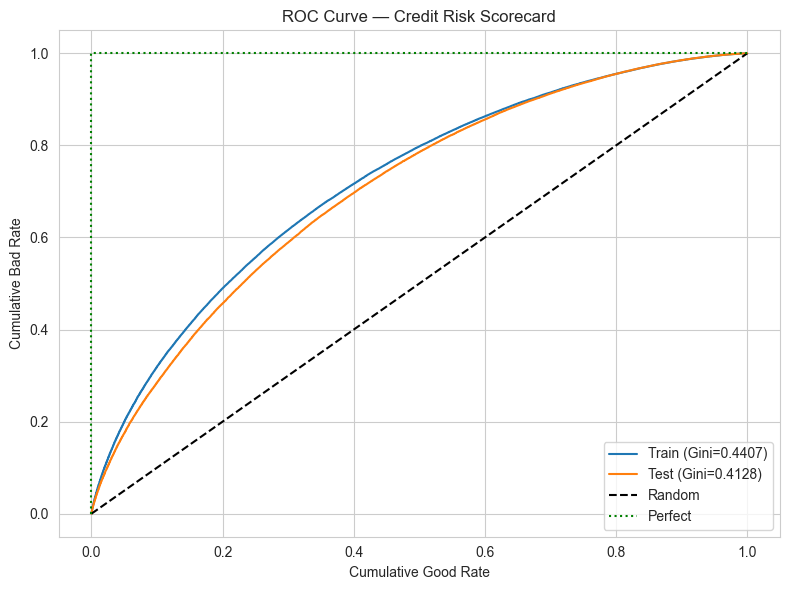

In [42]:
import matplotlib.pyplot as plt

def plot_roc_curve(y_true, y_prob, label, ax):
    sorted_indices = np.argsort(-y_prob)
    y_sorted = y_true.iloc[sorted_indices] if hasattr(y_true, 'iloc') else y_true[sorted_indices]
    
    total_bads = y_sorted.sum()
    total_goods = len(y_sorted) - total_bads
    
    cum_bads = np.cumsum(y_sorted) / total_bads
    cum_goods = np.cumsum(1 - y_sorted) / total_goods
    
    cum_bads = np.insert(cum_bads, 0, 0)
    cum_goods = np.insert(cum_goods, 0, 0)
    
    auc = np.trapezoid(cum_bads, cum_goods)
    gini = 2 * auc - 1
    
    ax.plot(cum_goods, cum_bads, label=f"{label} (Gini={gini:.4f})")

fig, ax = plt.subplots(figsize=(8, 6))

# Model curves
plot_roc_curve(y_train, train_probs, "Train", ax)
plot_roc_curve(y_test, test_probs, "Test", ax)

# Random line
ax.plot([0, 1], [0, 1], 'k--', label="Random")

# Perfect model
ax.plot([0, 0, 1], [0, 1, 1], 'g:', label="Perfect")

ax.set_xlabel("Cumulative Good Rate")
ax.set_ylabel("Cumulative Bad Rate")
ax.set_title("ROC Curve — Credit Risk Scorecard")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("../data/processed/roc_curve.png", dpi=150)
plt.show()

In [13]:
def compute_ks(y_true, y_prob):
    # Sort by predicted probability descending
    sorted_indices = np.argsort(-y_prob)
    y_sorted = y_true.iloc[sorted_indices] if hasattr(y_true, 'iloc') else y_true[sorted_indices]
    
    # Cumulative bad and good rates
    total_bads = y_sorted.sum()
    total_goods = len(y_sorted) - total_bads
    
    cum_bads = np.cumsum(y_sorted) / total_bads
    cum_goods = np.cumsum(1 - y_sorted) / total_goods
    
    # KS is the maximum difference between the two curves
    ks = np.max(np.abs(cum_bads - cum_goods))
    
    return ks

train_ks = compute_ks(y_train, train_probs)
test_ks = compute_ks(y_test, test_probs)

print(f"Train KS: {train_ks:.4f}")
print(f"Test KS:  {test_ks:.4f}")
print(f"Difference: {abs(train_ks - test_ks):.4f}")

Train KS: 0.3199
Test KS:  0.2975
Difference: 0.0224


In [44]:
metrics = {
    "Metric": ["Gini", "KS"],
    "Train": [train_gini, train_ks],
    "Test": [test_gini, test_ks],
    "Difference": [abs(train_gini - test_gini), abs(train_ks - test_ks)]
}

metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.round(4)
print(metrics_df.to_string(index=False))

Metric  Train   Test  Difference
  Gini 0.4407 0.4128      0.0279
    KS 0.3199 0.2975      0.0224


In [14]:
def compute_psi(expected, actual, bins=10):
    # Create bins based on expected (train) distribution 
    breakpoints = np.percentile(expected, np.linspace(0,100 ,bins + 1))
    breakpoints = np.unique(breakpoints) # remove duplicates 

    # bin both distributions 
    expected_counts = np.histogram(expected, bins = breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]

    #convert to proportions 
    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    # avoiding divisoin by 0 
    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct = np.where(actual_pct == 0, 0.0001, actual_pct)

    psi_bins = (actual_pct - expected_pct)*np.log(actual_pct/expected_pct)
    psi = psi_bins.sum() 

    return psi

psi = compute_psi(train_probs, test_probs)
print(f"PSI: {psi:.4f}")

PSI: 0.0044


In [48]:
# Add PSI to metrics summary
print("=" * 45)
print("MODEL VALIDATION SUMMARY")
print("=" * 45)
print(f"{'Metric':<10} {'Train':>8} {'Test':>8} {'Diff':>8}")
print("-" * 45)
print(f"{'Gini':<10} {train_gini:>8.4f} {test_gini:>8.4f} {abs(train_gini-test_gini):>8.4f}")
print(f"{'KS':<10} {train_ks:>8.4f} {test_ks:>8.4f} {abs(train_ks-test_ks):>8.4f}")
print(f"{'PSI':<10} {'N/A':>8} {psi:>8.4f} {'N/A':>8}")
print("=" * 45)

# Save metrics to csv
validation_df = pd.DataFrame({
    "Metric": ["Gini", "KS", "PSI"],
    "Train": [train_gini, train_ks, None],
    "Test": [test_gini, test_ks, psi],
    "Difference": [abs(train_gini-test_gini), abs(train_ks-test_ks), None]
})
validation_df.to_csv("../data/processed/validation_metrics.csv", index=False)
print("\nValidation metrics saved.")

MODEL VALIDATION SUMMARY
Metric        Train     Test     Diff
---------------------------------------------
Gini         0.4407   0.4128   0.0279
KS           0.3199   0.2975   0.0224
PSI             N/A   0.0044      N/A

Validation metrics saved.


In [49]:
def compute_scores(log_odds, PDO, anchor_score, anchor_odds):
    B = PDO / np.log(2)
    A = anchor_score + B * np.log(anchor_odds)
    scores = A - B * log_odds
    return scores

# Get log odds from predicted probabilities
train_log_odds = np.log(train_probs / (1 - train_probs))
test_log_odds = np.log(test_probs / (1 - test_probs))

# Compute scores with both anchor odds
scores_50_train = compute_scores(train_log_odds, PDO=20, anchor_score=600, anchor_odds=50)
scores_10_train = compute_scores(train_log_odds, PDO=20, anchor_score=600, anchor_odds=10)

print("=== Anchor Odds = 50:1 ===")
print(f"Min: {scores_50_train.min():.1f}")
print(f"Max: {scores_50_train.max():.1f}")
print(f"Mean: {scores_50_train.mean():.1f}")
print(f"Median: {np.median(scores_50_train):.1f}")

print("\n=== Anchor Odds = 10:1 ===")
print(f"Min: {scores_10_train.min():.1f}")
print(f"Max: {scores_10_train.max():.1f}")
print(f"Mean: {scores_10_train.mean():.1f}")
print(f"Median: {np.median(scores_10_train):.1f}")

=== Anchor Odds = 50:1 ===
Min: 683.2
Max: 851.8
Mean: 762.1
Median: 761.8

=== Anchor Odds = 10:1 ===
Min: 636.8
Max: 805.4
Mean: 715.7
Median: 715.4


In [51]:
import numpy as np 
import pandas as pd 

# Step 1 scaling paramters 
PDO = 20 
anchor_score = 600 
anchor_odds = 10 

# step 2 Derive A and B 
# A = intercept that anchor the scale 
# B = conversion factor between log-odds and score points 
B = PDO / np.log(2)
A = anchor_score + B * np.log(anchor_odds)

print(f"  Anchor Score: {anchor_score}")

print(f"Scaling Parameters:")
print(f"PDO:          {PDO}")
print(f"Anchor Score: {anchor_score}")
print(f"Anchor Odds:  {anchor_odds}:1")
print(f"B:            {B:.4f}")
print(f"A:            {A:.4f}")

# Step 3 Conver predicted probabilities to log-odds 
train_log_odds = np.log(train_probs / (1-train_probs))
test_log_odds = np.log(test_probs / (1-test_probs))

# Step 4 Comptue score 
train_scores = A - B * train_log_odds 
test_scores = A - B * test_log_odds 

# Step 5 : Distribution Summary 
print(f"\nTrain Score Distribution:")
print(f"  Min:    {train_scores.min():.1f}")
print(f"  Max:    {train_scores.max():.1f}")
print(f"  Mean:   {train_scores.mean():.1f}")
print(f"  Median: {np.median(train_scores):.1f}")
print(f"  Std:    {train_scores.std():.1f}")

print(f"\nTest Score Distribution:")
print(f"  Min:    {test_scores.min():.1f}")
print(f"  Max:    {test_scores.max():.1f}")
print(f"  Mean:   {test_scores.mean():.1f}")
print(f"  Median: {np.median(test_scores):.1f}")
print(f"  Std:    {test_scores.std():.1f}")


  Anchor Score: 600
Scaling Parameters:
PDO:          20
Anchor Score: 600
Anchor Odds:  10:1
B:            28.8539
A:            666.4386

Train Score Distribution:
  Min:    636.8
  Max:    805.4
  Mean:   715.7
  Median: 715.4
  Std:    25.2

Test Score Distribution:
  Min:    634.7
  Max:    801.3
  Mean:   716.4
  Median: 715.4
  Std:    25.1


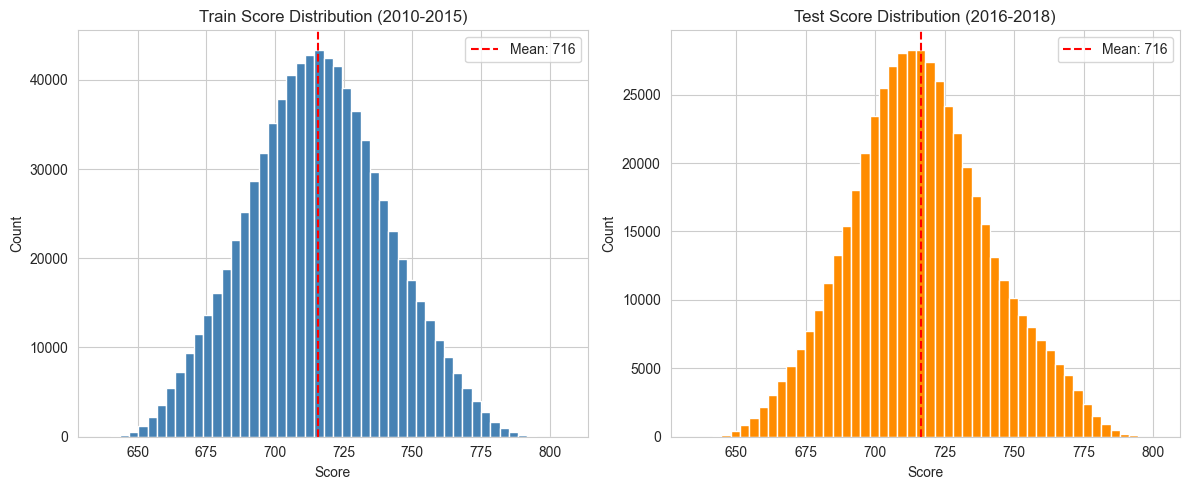

In [52]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train distribution
axes[0].hist(train_scores, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Train Score Distribution (2010-2015)")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")
axes[0].axvline(train_scores.mean(), color="red", linestyle="--", label=f"Mean: {train_scores.mean():.0f}")
axes[0].legend()

# Test distribution
axes[1].hist(test_scores, bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Test Score Distribution (2016-2018)")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Count")
axes[1].axvline(test_scores.mean(), color="red", linestyle="--", label=f"Mean: {test_scores.mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/score_distribution.png", dpi=150)
plt.show()

In [54]:
# Verify: higher score = lower default rate
train_score_df = pd.DataFrame({
    "score": train_scores,
    "target": y_train.values
})

# Bin scores into deciles and check default rate per decile
train_score_df["decile"] = pd.qcut(train_score_df["score"], q=10, labels=False)
decile_table = train_score_df.groupby("decile").agg(
    mean_score=("score", "mean"),
    default_rate=("target", "mean"),
    count=("target", "count")
).reset_index()

print(decile_table.to_string(index=False))

 decile  mean_score  default_rate  count
      0  672.148357      0.451823  81937
      1  688.674845      0.312280  81936
      2  698.116021      0.248963  81936
      3  705.538654      0.206720  81937
      4  712.178602      0.171829  81936
      5  718.606000      0.142782  81936
      6  725.269099      0.117139  81937
      7  732.826959      0.091181  81936
      8  742.699897      0.068248  81936
      9  760.487252      0.035991  81937


In [56]:
calib_df2 = pd.DataFrame({
    "predicted_prob": test_probs,
    "actual": y_test.values
})

calib_df2["prob_bin"] = pd.qcut(calib_df2["predicted_prob"], q=10, labels=False)

calib_table2 = calib_df2.groupby("prob_bin").agg(
    mean_predicted=("predicted_prob", "mean"),
    total=("actual", "count"),
    actual_defaults=("actual", "sum"),
    actual_default_rate=("actual", "mean")
).reset_index()

calib_table2["actual_non_defaults"] = calib_table2["total"] - calib_table2["actual_defaults"]
calib_table2["predicted_defaults"] = (calib_table2["mean_predicted"] * calib_table2["total"]).astype(int)
calib_table2["difference"] = abs(calib_table2["mean_predicted"] - calib_table2["actual_default_rate"])

print(calib_table2.to_string(index=False))
print(f"\nMean absolute calibration error: {calib_table2['difference'].mean():.4f}")

 prob_bin  mean_predicted  total  actual_defaults  actual_default_rate  actual_non_defaults  predicted_defaults  difference
        0        0.035802  51641             2364             0.045778                49277                1848    0.009976
        1        0.065744  51640             4661             0.090259                46979                3395    0.024515
        2        0.091697  51641             6327             0.122519                45314                4735    0.030822
        3        0.116215  51640             8114             0.157126                43526                6001    0.040911
        4        0.141418  51641             9921             0.192115                41720                7302    0.050696
        5        0.169197  51640            11549             0.223644                40091                8737    0.054448
        6        0.201488  51640            13565             0.262684                38075               10404    0.061195
        

In [57]:
print(f"Train default rate: {y_train.mean():.4f}")
print(f"Test default rate:  {y_test.mean():.4f}")

Train default rate: 0.1847
Test default rate:  0.2242


In [58]:
# Save scores
np.save("../data/processed/train_scores.npy", train_scores)
np.save("../data/processed/test_scores.npy", test_scores)

# Save decile table
decile_table.to_csv("../data/processed/decile_table.csv", index=False)

print("Scores and decile table saved.")

Scores and decile table saved.


In [60]:
train_check = pd.read_csv("../data/processed/train_selected.csv")
test_check = pd.read_csv("../data/processed/test_selected.csv")

categorical_cols = ["sub_grade", "term", "verification_status",
                    "home_ownership", "purpose"]

for col in categorical_cols:
    train_check[col] = train_check[col].astype("category")
    train_cats = set(train_check[col].cat.categories)
    test_cats = set(test_check[col].astype("category").cat.categories)
    unseen = test_cats - train_cats
    if unseen:
        print(f"{col}: unseen categories in test → {unseen}")
    else:
        print(f"{col}: no unseen categories ✓")

sub_grade: no unseen categories ✓
term: no unseen categories ✓
verification_status: no unseen categories ✓
home_ownership: no unseen categories ✓
purpose: no unseen categories ✓


In [4]:
import xgboost as xgb

train_xgb = pd.read_csv("../data/processed/train_selected.csv")
test_xgb = pd.read_csv("../data/processed/test_selected.csv")

categorical_cols = ["sub_grade", "term", "verification_status",
                    "home_ownership", "purpose"]

for col in categorical_cols:
    train_xgb[col] = train_xgb[col].astype("category")
    test_xgb[col] = pd.Categorical(test_xgb[col], 
                                    categories=train_xgb[col].cat.categories)

x_train_xgb = train_xgb.drop(columns=["target"])
y_train_xgb = train_xgb["target"]
x_test_xgb = test_xgb.drop(columns=["target"])
y_test_xgb = test_xgb["target"]

print(f"X_train shape: {x_train_xgb.shape}")
print(f"X_test shape: {x_test_xgb.shape}")

X_train shape: (819364, 30)
X_test shape: (516405, 30)


In [6]:
xgb_model = xgb.XGBClassifier(
    n_estimators = 300,
    max_depth = 4 , 
    learning_rate = 0.05 , 
    subsample = 0.8 , 
    colsample_bytree = 0.8 , 
    enable_categorical = True , 
    tree_method = "hist" , 
    eval_metric = "auc" , 
    random_state = 42 , 
    n_jobs = -1
)

xgb_model.fit(
    X_train_xgb, y_train_xgb , 
    eval_set = [(x_test_xgb , y_test_xgb)], 
    verbose = 100
)

print("XGBoost training complete.")

[0]	validation_0-auc:0.68231
[100]	validation_0-auc:0.70736
[200]	validation_0-auc:0.71235
[299]	validation_0-auc:0.71393
XGBoost training complete.


In [15]:
xgb_train_probs = xgb_model.predict_proba(x_train_xgb)[:,1]
xgb_test_probs = xgb_model.predict_proba(x_test_xgb)[:,1]

xgb_train_gini = compute_gini(y_train_xgb, xgb_train_probs)
xgb_test_gini = compute_gini(y_test_xgb, xgb_test_probs)
xgb_train_ks = compute_ks(y_train_xgb, xgb_train_probs)
xgb_test_ks = compute_ks(y_test_xgb, xgb_test_probs)
xgb_psi = compute_psi(xgb_train_probs, xgb_test_probs)

print("=" * 55)
print("MODEL COMPARISON — LR vs XGBoost")
print("=" * 55)
print(f"{'Metric':<10} {'LR Train':>10} {'LR Test':>10} {'XGB Train':>10} {'XGB Test':>10}")
print("-" * 55)
print(f"{'Gini':<10} {train_gini:>10.4f} {test_gini:>10.4f} {xgb_train_gini:>10.4f} {xgb_test_gini:>10.4f}")
print(f"{'KS':<10} {train_ks:>10.4f} {test_ks:>10.4f} {xgb_train_ks:>10.4f} {xgb_test_ks:>10.4f}")
print(f"{'PSI':<10} {psi:>10.4f} {'N/A':>10} {xgb_psi:>10.4f} {'N/A':>10}")
print("=" * 55)

MODEL COMPARISON — LR vs XGBoost
Metric       LR Train    LR Test  XGB Train   XGB Test
-------------------------------------------------------
Gini           0.4407     0.4128     0.4632     0.4279
KS             0.3199     0.2975     0.3380     0.3094
PSI            0.0044        N/A     0.0034        N/A


In [16]:
import pickle

with open("../data/processed/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

np.save("../data/processed/xgb_train_probs.npy", xgb_train_probs)
np.save("../data/processed/xgb_test_probs.npy", xgb_test_probs)

print("XGBoost model and probabilities saved.")

XGBoost model and probabilities saved.
